# Notebook per esportare pickle per streamlit 

Per i dataset Titanic e German vengono esportati:
* X train per le instance
* Explainer
* bbox - Il modello è un random forest
* La feature importance con Shap
* 20 istanze per dataset già spiegate


In [1]:
import pandas as pd
import numpy as np

from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import GradientBoostingClassifier

from xailib.data_loaders.dataframe_loader import prepare_dataframe

from xailib.explainers.lime_explainer import LimeXAITabularExplainer
from xailib.explainers.lore_explainer import LoreTabularExplainer
from xailib.explainers.shap_explainer_tab import ShapXAITabularExplainer

from xailib.models.sklearn_classifier_wrapper import sklearn_classifier_wrapper

import altair as alt

import os
from plot_explanation import PlotExplanation
import pickle

In [2]:
datasets=['titanic_c.csv','german_credit.csv']

## Titanic

In [3]:
source_file = f'../datasets/{datasets[0]}'
class_field = 'Survived'
# Load and transform dataset
df_t = pd.read_csv(source_file, skipinitialspace=True, na_values='?', keep_default_na=True)

In [4]:
df_t, feature_names, class_values, numeric_columns, rdf, real_feature_names, features_map = prepare_dataframe(df_t, class_field)

### Learning a Random Forest classfier

We train a RF classifier by using the ```sklearn``` library. We start by splitting the dataset into a train and test subsets. 

In [5]:
test_size = 0.3
random_state = 42
X_train_t, X_test_t, Y_train_t, Y_test_t = train_test_split(df_t[feature_names], df_t[class_field],
                                                        test_size=test_size,
                                                        random_state=random_state,
                                                        stratify=df_t[class_field])

In [6]:
bb_t = RandomForestClassifier(n_estimators=20, random_state=random_state)
bb_t.fit(X_train_t.values, Y_train_t.values)
bbox_t = sklearn_classifier_wrapper(bb_t)

### Export Pickle for X_train and bbox

In [7]:
dataset_dict_tit = {"X_train_titanic": X_train_t, "X_test_titanic": X_test_t, "y_train_titanic": Y_train_t, "y_test_titanic": Y_test_t}
path="../datasets/titanic/train_test_titanic.pkl"

In [ ]:
with open(path, 'wb') as train_test_titanic:
    pickle.dump(dataset_dict_tit, train_test_titanic)

In [ ]:
pickle.dump(bbox_t, open('../datasets/titanic/bbox_titanic.pkl', 'wb'))

In [8]:
inst= X_train_t.iloc[4].values
inst

array([ 3.  ,  1.  , 28.  ,  1.  ,  0.  , 15.85,  2.  ])

In [ ]:
print('Instance ',inst)
print('True class ',Y_train_t.iloc[4])
print('Predicted class ',bb_t.predict(inst.reshape(1, -1)))

In [ ]:
inst

### Export the explainer

In [9]:
explainer_t = LoreTabularExplainer(bbox_t)
config = {'neigh_type':'geneticp', 'size':1000, 'ocr':0.1, 'ngen':10}
explainer_t.fit(df_t, class_field, config)
#pickle.dump(explainer_t, open('../datasets/titanic/explainer_titanic.pkl', 'wb'))

In [ ]:
explainer_t.explain(inst)

### Export the feature Importance

In [10]:
explainer_s_t = ShapXAITabularExplainer(bbox_t, feature_names)
config = {'explainer' : 'tree', 'X_train' : X_train_t.iloc[0:100].values}
explainer_s_t.fit(config)
#pickle.dump(explainer_s_t, open('../datasets/titanic/shap_featureimportance_titanic.pkl', 'wb'))

In [14]:
exp_t = explainer_s_t.explain(inst)

In [16]:
exp_t

In [17]:
shap_feature_importance_t=exp_t.exp
shap_feature_importance_t

[array([0.05785741, 0.10758353, 0.0709937 , 0.01493528, 0.01607778,
        0.07587915, 0.03636818]),
 array([-0.05785741, -0.10758353, -0.0709937 , -0.01493528, -0.01607778,
        -0.07587915, -0.03636818])]

## Export the pickle with instances explained

In [ ]:
#list_of_inst_t=X_train_t.iloc[0:2].values

In [11]:
dfnew_t= X_train_t.iloc[0:20]

In [18]:
row_list=[]
list_exp_inst_t=[]
exp_list_t=[]
elem_list_3_t=[]
shap_list_t=[]
n=0
for index, row in dfnew_t.iterrows():
    row_dict = {}
    #dizionario per riga del df
    #row_list.append(row.tolist()) #creo una lista delle istanze da spiegare
    #for inst_t in row_list: #per ogni instanza della lista
    exp = explainer_t.explain(row.values) #spiego l'istanza, explainer t è stato trainato prima
    exp_list_t.append(exp) # la appendo a una nuova lista
    for col in dfnew_t.columns: # per ogni colonna del df
        row_dict[col] = row[col]# creo un dizionario
    row_list.append(row_dict)
    # feature importance con shap
    exp_shap_t = explainer_s_t.explain(row)
    shap_feature_importance_t = exp_shap_t.exp
    shap_list_t.append(shap_feature_importance_t)
    # appendo i 3 elementi in una lista
    elem_list_3_t = [exp_list_t[-1], row_dict, shap_list_t[-1]]
    list_exp_inst_t.append(elem_list_3_t) #lista finale
    n+=1
    print(exp)
    print(n)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20


In [25]:
print(type(list_exp_inst_t[3][2][1]))
print(list_exp_inst_t[3][2])

<class 'numpy.ndarray'>
[array([-0.07507886,  0.22210613,  0.04074621,  0.00323307,  0.00826952,
        0.16221608,  0.01820287]), array([ 0.07507886, -0.22210613, -0.04074621, -0.00323307, -0.00826952,
       -0.16221608, -0.01820287])]


In [26]:
pickle.dump(list_exp_inst_t, open('../datasets/titanic/instances_explained_titanic.pkl', 'wb'))

In [ ]:
inst_dict=X_train_t.iloc[0:2].to_dict('index')

In [ ]:
exp.expDict['rule']['premise']

In [ ]:
rules =exp.expDict['rule']['premise']

In [ ]:
for r in rules:
    print(r.values())

In [ ]:
print(exp.expDict['rule']['premise'])

In [ ]:
#pickle.dump(list_exp_t, open('../datasets/titanic/instances_explained_titanic.pkl', 'wb'))

## German

In [3]:
source_file = f'../datasets/{datasets[1]}'
class_field = 'default'
# Load and transform dataset
df_g = pd.read_csv(source_file, skipinitialspace=True, na_values='?', keep_default_na=True)

In [4]:
df_g, feature_names, class_values, numeric_columns, rdf, real_feature_names, features_map = prepare_dataframe(df_g, class_field)

### Learning a Random Forest classfier

We train a RF classifier by using the ```sklearn``` library. We start by splitting the dataset into a train and test subsets. 

In [5]:
test_size = 0.3
random_state = 42
X_train_g, X_test_g, Y_train_g, Y_test_g= train_test_split(df_g[feature_names], df_g[class_field],
                                                        test_size=test_size,
                                                        random_state=random_state,
                                                        stratify=df_g[class_field])

In [6]:
clf = GradientBoostingClassifier(n_estimators=30, learning_rate=0.5,
max_depth=2, random_state=random_state).fit(X_train_g, Y_train_g)
clf.score(X_test_g, Y_test_g)

0.7733333333333333

NameError: name 'plt' is not defined

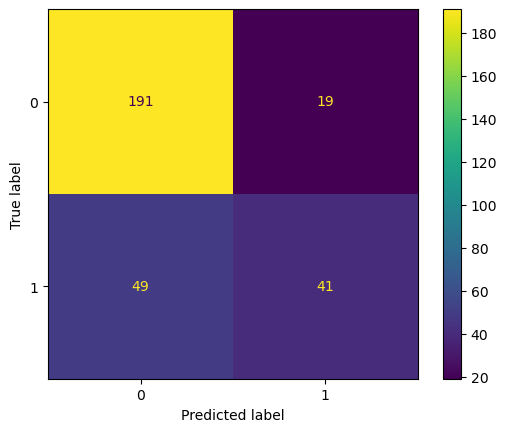

In [7]:
predictions = clf.predict(X_test_g)
cm = confusion_matrix(Y_test_g, predictions, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()
plt.show()

In [8]:
bb_g = RandomForestClassifier(n_estimators=30, random_state=42)
bb_g.fit(X_train_g.values, Y_train_g.values)
bbox_g = sklearn_classifier_wrapper(bb_g)

In [9]:
Y_test_g

115    0
346    0
328    0
974    0
587    0
      ..
485    1
647    1
860    0
433    0
200    0
Name: default, Length: 300, dtype: int64

In [32]:
# Predict probabilities for the test set
probabilities = bb_g.predict_proba(X_test_g)
for index in range(0,10):
    # Example: Print the probability of the first test instance
    print("the index is", index)
    print("Predicted class for first test instance:", probabilities[index].argmax())
    print("Confidence of the prediction:", probabilities[index].max())
    print("True prediction:=", Y_test_g.iloc[index])

the index is 0
Predicted class for first test instance: 0
Confidence of the prediction: 0.9666666666666667
True prediction:= 0
the index is 1
Predicted class for first test instance: 0
Confidence of the prediction: 0.6666666666666666
True prediction:= 0
the index is 2
Predicted class for first test instance: 1
Confidence of the prediction: 0.5666666666666667
True prediction:= 0
the index is 3
Predicted class for first test instance: 0
Confidence of the prediction: 0.9666666666666667
True prediction:= 0
the index is 4
Predicted class for first test instance: 0
Confidence of the prediction: 0.8333333333333334
True prediction:= 0
the index is 5
Predicted class for first test instance: 0
Confidence of the prediction: 0.9666666666666667
True prediction:= 0
the index is 6
Predicted class for first test instance: 0
Confidence of the prediction: 0.9666666666666667
True prediction:= 0
the index is 7
Predicted class for first test instance: 0
Confidence of the prediction: 0.6333333333333333
True

NameError: name 'plt' is not defined

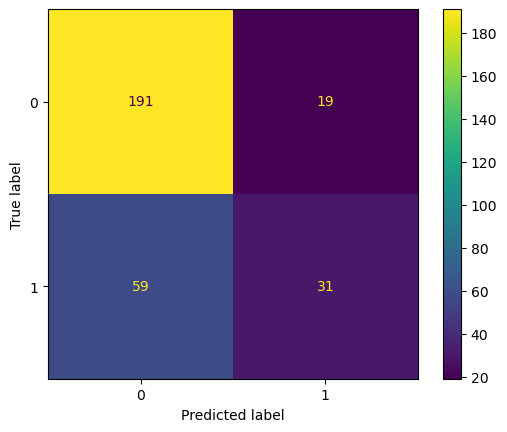

In [15]:
predictions = bb_g.predict(X_test_g)
cm = confusion_matrix(Y_test_g, predictions, labels=bb_g.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bb_g.classes_)
disp.plot()
plt.show()

### Export Pickle for X_train and bbox

In [11]:
dataset_dict_ger = {"X_train_german": X_train_g, "X_test_german": X_test_g, "y_train_german": Y_train_g, "y_test_german": Y_test_g}
path="../datasets/german/train_test_german.pkl"
with open(path, 'wb') as train_test_german:
    pickle.dump(dataset_dict_ger, train_test_german)

In [12]:
pickle.dump(bbox_g, open('../datasets/german/bbox_german.pkl', 'wb'))

In [13]:
inst_g = X_train_g.iloc[4].values
print('Instance ',inst_g)
print('True class ',Y_train_g.iloc[4])
print('Predicted class ',bb_g.predict(inst_g.reshape(1, -1)))

Instance  [11 7228 1 4 39 2 1 False False False True False True False False False
 False False True False False False False False False False False True
 False False False False False True False False False False False True
 False False True True False False False False True False False True False
 False False False True True False False True]
True class  0
Predicted class  [0]


### Export the explainer

In [14]:
explainer_g = LoreTabularExplainer(bbox_g)
config = {'neigh_type':'geneticp', 'size':1000, 'ocr':0.1, 'ngen':10}
explainer_g.fit(df_g, class_field, config)
pickle.dump(explainer_g, open('../datasets/german/explainer_german.pkl', 'wb'))


In [15]:
exp = explainer_g.explain(inst_g)
print(exp)

### Export the feature Importance

In [16]:
explainer_s_g = ShapXAITabularExplainer(bbox_g, feature_names)
config = {'explainer' : 'tree', 'X_train' : X_train_g.iloc[0:100].values}
explainer_s_g.fit(config)
#pickle.dump(explainer_s_g, open('../datasets/german/shap_featureimportance_german.pkl', 'wb'))

In [17]:
exp_g = explainer_s_g.explain(inst_g)

In [18]:
shap_feature_importance=exp_g.exp

## Export the pickle with instances explained

In [ ]:
list_of_inst_g=X_train_g.iloc[0:20].values

In [ ]:
list_of_inst_g[2]

In [ ]:
#list_exp_g=[]
#for inst_g in list_of_inst_g:
#    exp = explainer_g.explain(inst_g)
#    list_exp_g.append(exp)
#    print(exp)

In [ ]:
list_exp_g[1].getExemplars

In [ ]:
list_exp_g[1].expDict['rule']['premise']

In [ ]:
pickle.dump(list_exp_g, open('../datasets/german/instances_explained_german.pkl', 'wb'))

## Export the instances explained

In [19]:
dfnew_g= X_train_g.iloc[[0,1,11,13,119,172,174,176]]

In [20]:
row_list_g=[]
list_exp_inst_g=[]
exp_list_g=[]
elem_list_3_g=[]
shap_list_g=[]
n=0
for index, row in dfnew_g.iterrows():
    row_dict = {} #dizionario per riga del df
    #row_list_g.append(row.tolist()) #creo una lista delle istanze da spiegare
   #per ogni instanza della lista
    exp = explainer_g.explain(row.values) #spiego l'istanza, explainer g è stato trainato prima
    exp_list_g.append(exp) # la appendo a una nuova lista
    for col in dfnew_g.columns: # per ogni colonna del df
        row_dict[col] = row[col]# creo un dizionario
    row_list_g.append(row_dict)
    # feature importance con shap
    exp_shap_g = explainer_s_g.explain(row)
    shap_feature_importance_g=exp_shap_g.exp
    shap_list_g.append(shap_feature_importance_g)
    # appendo i 3 elementi in una lista
    elem_list_3_g = [exp_list_g[-1], row_dict, shap_list_g[-1]]
    list_exp_inst_g.append(elem_list_3_g) #lista finale
    n+=1
    print(exp)
    print(n)

1
2
3
4
5
6
7
8


In [21]:
print(list_exp_inst_g)

[[<xailib.explainers.lore_explainer.LoreTabularExplanation object at 0x7fad309a2670>, {'duration_in_month': 12, 'credit_amount': 1295, 'installment_as_income_perc': 3, 'present_res_since': 1, 'age': 25, 'credits_this_bank': 1, 'people_under_maintenance': 1, 'account_check_status=0 <= ... < 200 DM': True, 'account_check_status=< 0 DM': False, 'account_check_status=>= 200 DM / salary assignments for at least 1 year': False, 'account_check_status=no checking account': False, 'credit_history=all credits at this bank paid back duly': False, 'credit_history=critical account/ other credits existing (not at this bank)': False, 'credit_history=delay in paying off in the past': False, 'credit_history=existing credits paid back duly till now': True, 'credit_history=no credits taken/ all credits paid back duly': False, 'purpose=(vacation - does not exist?)': False, 'purpose=business': False, 'purpose=car (new)': True, 'purpose=car (used)': False, 'purpose=domestic appliances': False, 'purpose=educ

In [38]:
pickle.dump(list_exp_inst_g, open('../datasets/german/instances_explained_german.pkl', 'wb'))

## ExPORT JSON D3

In [24]:
import json

In [25]:
def parse_dict_first(lore_obj): #creo un dizionario dell'istanza, alcuni oggetti però vanno parsati meglio
    istance = lore_obj.__dict__
    return istance

def update_object(istance):
    istance.update(
    {'rule': rule_list,
     'crules':counterrule_list,
     'exemplars':exemplars_list,
     'dt':dt_dict,
     'distribution':data_desc,
     'inst':inst_dict,
     'fi_shap':fi_shap
    })
    return istance   

In [26]:
class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return json.JSONEncoder.default(self, obj)

In [29]:
list_exp_inst_g

[[<xailib.explainers.lore_explainer.LoreTabularExplanation at 0x7fad309a2670>,
  {'duration_in_month': 12,
   'credit_amount': 1295,
   'installment_as_income_perc': 3,
   'present_res_since': 1,
   'age': 25,
   'credits_this_bank': 1,
   'people_under_maintenance': 1,
   'account_check_status=0 <= ... < 200 DM': True,
   'account_check_status=< 0 DM': False,
   'account_check_status=>= 200 DM / salary assignments for at least 1 year': False,
   'account_check_status=no checking account': False,
   'credit_history=all credits at this bank paid back duly': False,
   'credit_history=critical account/ other credits existing (not at this bank)': False,
   'credit_history=delay in paying off in the past': False,
   'credit_history=existing credits paid back duly till now': True,
   'credit_history=no credits taken/ all credits paid back duly': False,
   'purpose=(vacation - does not exist?)': False,
   'purpose=business': False,
   'purpose=car (new)': True,
   'purpose=car (used)': False,

In [31]:
for index, in list_exp_inst_g.items():
    filename = f"../JSON_istance/istance_german_{index}.json"
    with open(filename, "w") as file:
        json.dump(data, file, cls=NpEncoder)

AttributeError: 'list' object has no attribute 'items'